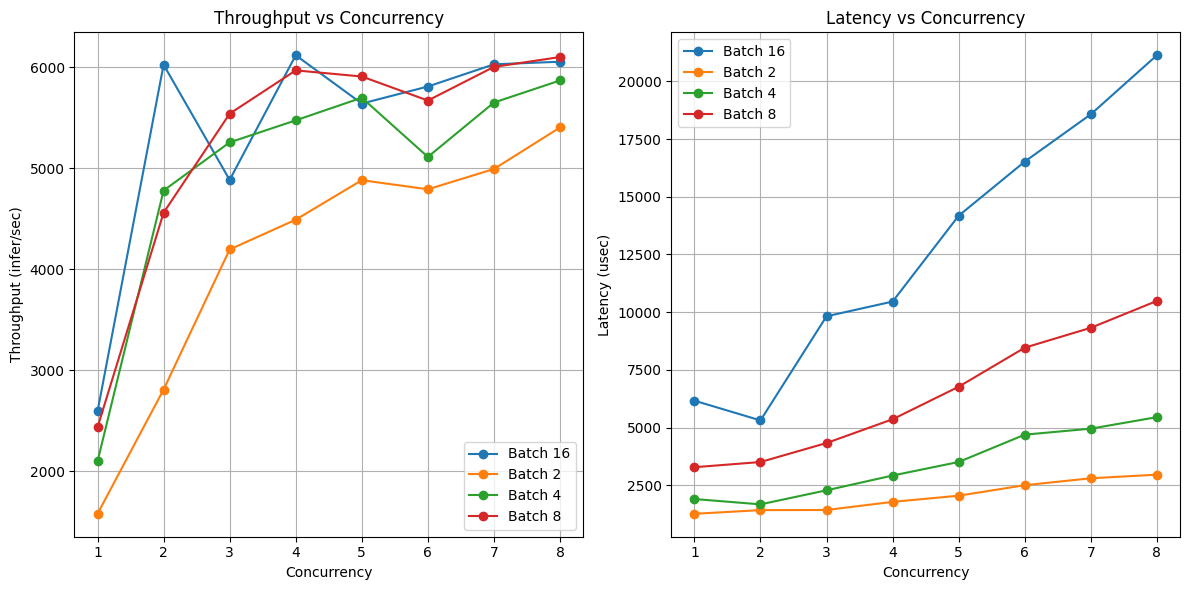

In [3]:
import os
import re
import matplotlib.pyplot as plt

log_dir = "."
log_files = [f for f in os.listdir(log_dir) if f.startswith("perf_log_batch")]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for file in sorted(log_files):
    batch_size = re.search(r"batch(\d+)", file).group(1)
    concurrency, throughput = [], []

    with open(os.path.join(log_dir, file), "r") as f:
        for line in f:
            match = re.search(r"Concurrency: (\d+), throughput: ([\d.]+) infer/sec", line)
            if match:
                concurrency.append(int(match.group(1)))
                throughput.append(float(match.group(2)))
    
    plt.plot(concurrency, throughput, marker='o', label=f"Batch {batch_size}")

plt.title("Throughput vs Concurrency")
plt.xlabel("Concurrency")
plt.ylabel("Throughput (infer/sec)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for file in sorted(log_files):
    batch_size = re.search(r"batch(\d+)", file).group(1)
    concurrency, latency = [], []

    with open(os.path.join(log_dir, file), "r") as f:
        for line in f:
            match = re.search(r"Concurrency: (\d+), .* latency (\d+) usec", line)
            if match:
                concurrency.append(int(match.group(1)))
                latency.append(int(match.group(2)))

    plt.plot(concurrency, latency, marker='o', label=f"Batch {batch_size}")

plt.title("Latency vs Concurrency")
plt.xlabel("Concurrency")
plt.ylabel("Latency (usec)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()